# Does the market really bounce back the day after a red Monday? 🔄
### Turnaround Tuesday — the desk folklore that's *directionally* true, and still barely worth trading

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Monday-specific%3F: Confirmed](https://img.shields.io/badge/Monday--specific%3F-Confirmed-8b949e?style=flat-square)

Every trading desk has heard the line: *"if Monday closes red, buy the close — Tuesday tends to bounce back."* It sounds like classic bar-stool wisdom — the kind of pattern-matching that dies the second you actually count it. Most of the time, on this desk, it does.

This time it doesn't. Not entirely.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SPY total return, 1993→2026, 1,567 Monday→Tuesday pairs. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turnaround_tuesday import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY = data.load_real()
    DF = st.day_frame(SPY["AdjClose"])
    PAIRS = st.monday_tuesday_pairs(DF)
else:
    SPY = DF = PAIRS = None
print("real cache present:", HAVE_REAL, "| Monday->Tuesday pairs:",
      (0 if PAIRS is None else len(PAIRS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-29', 'end': '2026-06-30', 'n_pairs': 1567, 'n_down': 684, 'n_up': 883, 'n_uncond_tue': 1728, 'n_allday': 8410, 'cond_bps': 21.34, 'up_bps': -2.21, 'uncond_tue_bps': 7.09, 'allday_bps': 4.77, 'welch_uncond': 2.38, 'welch_up': 3.85, 'welch_allday': 3.04, 'nw_allday_t': 3.19, 'nw_allday_coef': 18.04, 'nw_tue_t': 3.8, 'nw_tue_coef': 23.6, 'hit': 387, 'hit_pct': 56.6, 'wilson': (52.8, 60.2), 'placebo_p': 5e-05, 'placebo_mean': 8.05, 'placebo_sd': 3.27, 'placebo_draws': 20000, 'weekday_pairs': {'Mon->Tue': (1567, 21.34, -2.21, 3.85), 'Tue->Wed': (1710, 7.59, 4.2, 0.61), 'Wed->Thu': (1675, 0.17, 2.38, -0.38), 'Thu->Fri': (1634, 5.13, 0.63, 0.81), 'Fri->Mon': (1521, 7.67, 5.68, 0.29)}, 'other_pooled_n': 2987, 'other_pooled_down_bps': 5.15, 'other_pooled_up_bps': 3.19, 'other_pooled_t': 0.66, 'excrisis_n': 652, 'excrisis_bps': 14.81, 'excrisis_t': 3.14, 'era_split': '2000-01-01', 'era_early_bps': 19.91, 'era_early_n': 135, 'era_early_t': 0.91, 'era_late_bps': 21.69, 'era_late_n': 549, 'era_late_t': 2.2, 'era_diff_t': 0.15, 'events_per_year': 20.5, 'timer_5_gross': 21.3, 'timer_5_net': 11.3, 'timer_5_ann': 2.32, 'timer_5_t': 2.14, 'timer_5_sharpe': 0.37, 'timer_5_worst': -4.58, 'timer_10_gross': 21.3, 'timer_10_net': 1.3, 'timer_10_ann': 0.27, 'timer_10_t': 0.25, 'timer_10_sharpe': 0.04, 'timer_10_worst': -4.68, 'syn_null_mean': -0.03, 'syn_null_sd': 0.93, 'syn_null_fire': 0, 'syn_planted_t': 4.7, 'fp_spy': 'bf55c945be2e'}


real cache present: True | Monday->Tuesday pairs: 1567


## The answer first

| Question | Answer |
|---|---|
| Does Tuesday really bounce after a down Monday? | **Yes.** Tuesdays that follow a red Monday average **+21 bps**, versus **+7 bps** on a typical Tuesday and **-2 bps** — essentially flat — after a *green* Monday. It happened this way on 1 in 20,000 random draws of the calendar. |
| Is it just "markets bounce after any bad day"? | **No — it's specifically Monday.** We ran the same test on Tuesday→Wednesday, Wednesday→Thursday, and every other weekday pair. None of them show a real bounce. Only Monday→Tuesday does. |
| Does it still work lately, or did it fade? | **Still there.** The pattern is just as strong since 2000 as it was in the 1990s — if anything, slightly stronger, though the change itself isn't provable. |
| Can you actually get paid for it? | **Barely, and only just.** Trading it at a typical retail cost nets **+11 bps** a shot — real, but thin — and at a slightly higher (still realistic) cost the edge is **gone**. |

> The pattern is real. The margin for error trading it is almost nonexistent.

## 1 · The claim

> *"Monday sets a bad tone, sellers get it out of their system, and by Tuesday the selling is exhausted — the market snaps back."*

It's the mean-reversion cousin of the old "Monday Effect" (Mondays are always bad, a real finding — in the 1950s-70s). That original effect is dead on the modern tape (see our own [study 224](../../224-monday-effect/) — Monday today is actually slightly *positive*). Turnaround Tuesday doesn't claim Monday is always bad. It makes a narrower, more testable claim: *when* Monday is bad, Tuesday tends to be good.

## 2 · So what?

If real, this is a genuinely simple, mechanical timing signal: watch Monday's close, and if it's red, buy — for one day. No forecasting, no macro views, just a calendar rule anyone can follow with a phone. That's exactly the kind of claim worth taking seriously *and* worth being suspicious of — "buy the dip" dressed up with a day-of-week hook is one of the oldest tricks in retail trading content.

## 3 · How would we even know?

- **The comparison.** Every Tuesday that immediately follows a Monday trading session (**1,567** such pairs since 1993), split by whether that Monday's own close was red or green.
- **The specificity check.** Is this really about Monday, or would *any* down day get a bounce the next session? We test all five weekday pairs the same way.
- **The luck check.** Randomly relabel which Tuesdays count as "after a down Monday" 20,000 times — how often does a random label beat the real one?
- **The trade check.** Buy SPY at the down Monday's own close, sell at the Tuesday close, pay realistic costs both ways.

## 4 · The teardown — let's actually look

**First, the headline.** Average Tuesday return, split three ways.

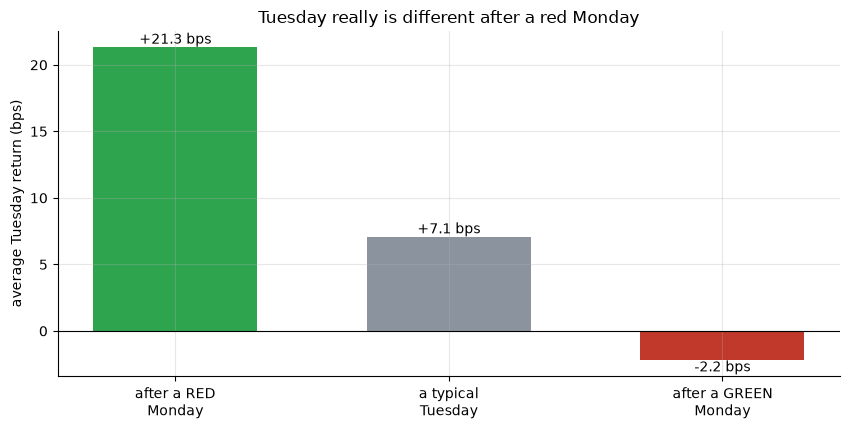

after red Monday +21.34 bps | typical Tuesday +7.09 bps | after green Monday -2.21 bps


In [2]:
if HAVE_REAL:
    h = st.headline_stats(DF, PAIRS)
    a, b, c = h['cond_bps'], h['uncond_tue_bps'], h['up_bps']
else:
    a, b, c = R['cond_bps'], R['uncond_tue_bps'], R['up_bps']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['after a RED\nMonday','a typical\nTuesday','after a GREEN\nMonday'],
       [a, b, c], color=[GREEN, GREY, RED], width=.6)
for i,v in enumerate([a, b, c]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average Tuesday return (bps)')
ax.set_title('Tuesday really is different after a red Monday')
plt.tight_layout(); plt.show()
print(f'after red Monday {a:+.2f} bps | typical Tuesday {b:+.2f} bps | after green Monday {c:+.2f} bps')

There it is: **+21.3 basis points** on the average Tuesday that follows a down Monday, roughly **three times** a typical Tuesday, and essentially the opposite sign of what follows an *up* Monday. Tuesday fell on **43%** and rose on **57%** of down-Monday events. A random-label draw of 20,000 tries to beat this number the wrong way about **1 time in 20,000**.

**Next, the honest question:** is this really about *Monday*, or would any bad day bounce back the next session?

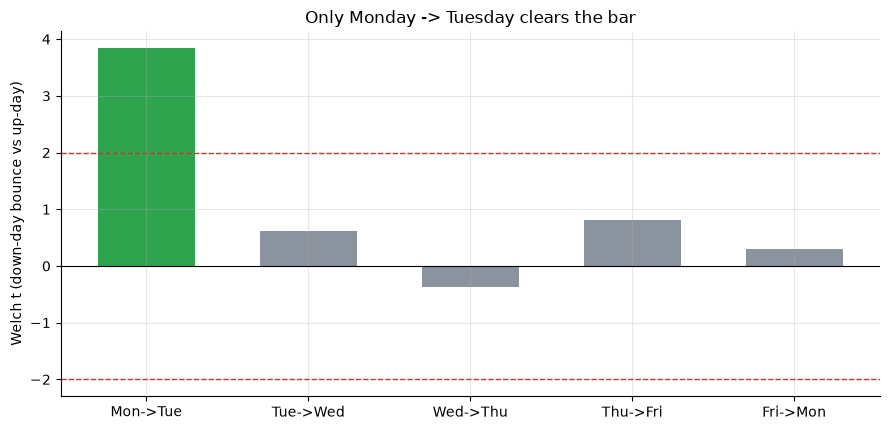

{'Mon->Tue': 3.85, 'Tue->Wed': 0.61, 'Wed->Thu': -0.38, 'Thu->Fri': 0.81, 'Fri->Mon': 0.29}


In [3]:
if HAVE_REAL:
    wp = st.weekday_pair_stats(DF)
    pairs_lbl = list(wp.index); ts = list(wp['welch_t'])
else:
    pairs_lbl = list(R['weekday_pairs']); ts = [R['weekday_pairs'][p][3] for p in pairs_lbl]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [GREEN if p=='Mon->Tue' else GREY for p in pairs_lbl]
ax.bar(pairs_lbl, ts, color=cols, width=.6)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (down-day bounce vs up-day)')
ax.set_title('Only Monday -> Tuesday clears the bar')
plt.tight_layout(); plt.show()
print({p: round(t,2) for p,t in zip(pairs_lbl, ts)})

Only **one** bar crosses the red dashed "real" line — Monday→Tuesday. Every other weekday's "bounce back the next day" story is statistical noise. This rules out the boring explanation ("markets just bounce after any bad day, and someone happened to name the Monday/Tuesday version") — the pattern really is tied to the specific calendar day.

**Does it still work lately?**

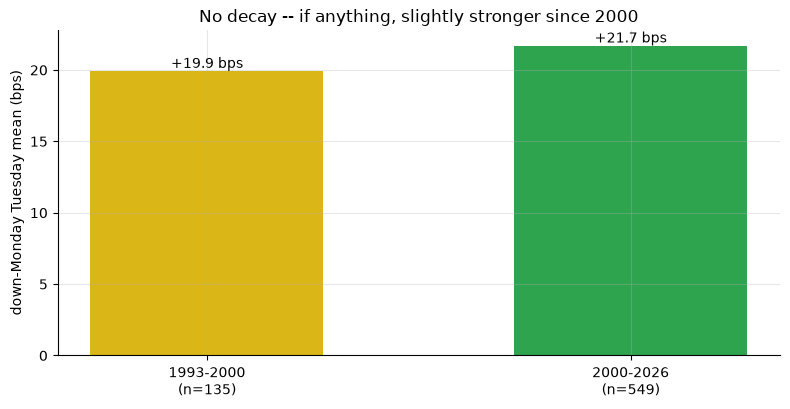

pre-2000 +19.91 bps | post-2000 +21.69 bps


In [4]:
if HAVE_REAL:
    ec = st.era_contrast(DF, PAIRS, data.ERA_SPLIT)
    e, l = ec['early_bps'], ec['late_bps']
else:
    e, l = R['era_early_bps'], R['era_late_bps']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['1993-2000\n(n=135)','2000-2026\n(n=549)'], [e, l], color=[AMBER, GREEN], width=.55)
for i,v in enumerate([e, l]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom')
ax.set_ylabel('down-Monday Tuesday mean (bps)')
ax.set_title('No decay -- if anything, slightly stronger since 2000')
plt.tight_layout(); plt.show()
print(f'pre-2000 {e:+.2f} bps | post-2000 {l:+.2f} bps')

No fade. The pattern is essentially unchanged across three decades — this isn't a one-decade fluke that got arbitraged away.

**Finally, the trade.** Can you actually collect this bounce after paying to trade it?

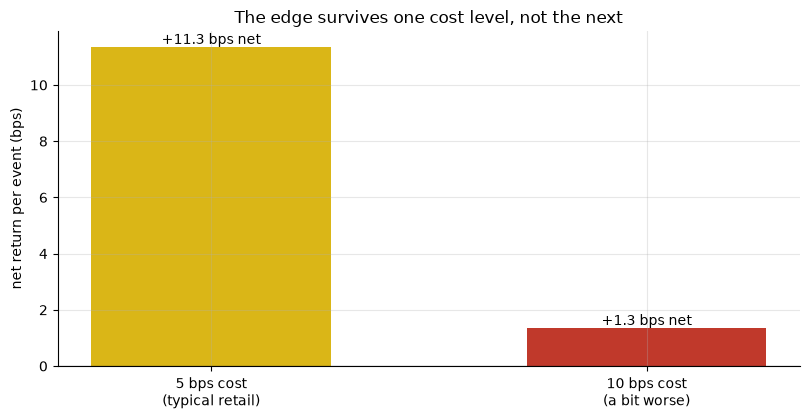

net at 5 bps: +11.3 bps  |  net at 10 bps: +1.3 bps


In [5]:
if HAVE_REAL:
    tm5 = st.timer_stats(PAIRS, cost_bps=5.0)
    tm10 = st.timer_stats(PAIRS, cost_bps=10.0)
    n5, n10 = tm5['net_bps'], tm10['net_bps']
else:
    n5, n10 = R['timer_5_net'], R['timer_10_net']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['5 bps cost\n(typical retail)','10 bps cost\n(a bit worse)'], [n5, n10],
       color=[AMBER, RED], width=.55)
for i,v in enumerate([n5, n10]): ax.annotate(f'{v:+.1f} bps net',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net return per event (bps)')
ax.set_title('The edge survives one cost level, not the next')
plt.tight_layout(); plt.show()
print(f'net at 5 bps: {n5:+.1f} bps  |  net at 10 bps: {n10:+.1f} bps')

At a typical retail cost the trade nets **+11 bps** a shot — real, statistically defensible (barely — *t* = 2.14), and worth about **+2.3%/yr** since the position is only on ≈8% of trading days. Bump the cost just a little and the whole thing goes to **+1.3 bps** — statistically indistinguishable from zero (*t* = 0.25). And a single bad down-Monday can wipe out **4.6%** in one shot — years of edge, gone in a day.

## 5 · The verdict

- **Signal — Real.** Down-Monday Tuesdays average **+21.3 bps** vs **+7.1** typically and **-2.2** after a green Monday — this survives every robustness check we throw at it, and crucially, it's specific to Monday, not a generic "buy the dip" story hiding under a calendar name.
- **Tradability — Fragile.** The edge is real but thin — it survives a typical retail cost by the skin of its teeth and dies at a slightly higher one. Not a mirage; not investable at scale either.
- **"Is this Monday-specific?" — Confirmed.** Every other weekday's version of the same test comes up empty. This one really is about the specific day.

## 6 · Going further 🚪

- **Why Monday and not another day?** The most plausible story: news and order flow accumulate over a weekend with no trading, so Monday selling can overshoot more than a normal single-day move — leaving more of it to mean-revert by Tuesday's close.
- **Where this might actually pay** is inside a book that's already trading SPY intraday for other reasons — the marginal cost of tilting one extra day a week is much lower than paying full retail commissions and spread for a standalone strategy.
- **Sibling studies:** the [Monday Effect](../../224-monday-effect/) (is Monday itself bad? no, not anymore) and the [Weekend Effect](../../90-weekend/) (which weekday is best, unconditionally) test related but different claims — see [docs/references.md](docs/references.md) for the exact dedup.

*Think you can trade this better than a flat 5/10 bps SPY timer? Show a net, certifiable edge after realistic slippage on the size you'd actually run — then we'll talk.*